# 07. Interpretabilidad de la red neuronal con SHAP

Esta última etapa explica las predicciones de la red neuronal mediante valores SHAP. Se estudian la importancia global, casos individuales, relaciones de dependencia y diferencias en las contribuciones por grupos sensibles.

Para mantener un coste computacional razonable, el cálculo se realiza sobre muestras controladas de entrenamiento y prueba.

**Entrada:** `data/processed/df_lasso2.csv`.


## Alcance del cálculo

SHAP puede resultar costoso en redes neuronales y conjuntos de datos grandes. Por ello se emplean una muestra de referencia del entrenamiento y una muestra del conjunto de prueba. Los parámetros `BACKGROUND_SIZE`, `EXPLAIN_SIZE` y `NSHAP_SAMPLES` permiten ajustar el equilibrio entre precisión y tiempo de ejecución.


In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
shap.initjs()


In [21]:
TARGET_COL = "target"
SENSITIVE_COLS = ["sexo", "raza", "etnia"]
DROP_COLS = []
DATA_PATH = "data/processed/df_lasso2.csv"

RANDOM_STATE = 42
TEST_SIZE = 0.20
VALID_SIZE_WITHIN_TRAIN = 0.20
THRESHOLD_GRID = np.linspace(0.10, 0.90, 81)

# Parametros SHAP pensados para un dataset grande
BACKGROUND_SIZE = 200
EXPLAIN_SIZE = 500
NSHAP_SAMPLES = 100
TOP_N = 15


## Helpers


In [4]:
def make_ohe():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def normalize_binary_target(series):
    values = sorted(pd.Series(series).dropna().unique().tolist())
    if values not in ([0, 1], [0], [1]):
        raise ValueError(f"La variable objetivo debe ser binaria. Valores encontrados: {values}")
    return series.astype(int)


def build_feature_lists(frame, target_col, drop_cols=None):
    drop_cols = drop_cols or []
    feature_cols = [c for c in frame.columns if c not in [target_col] + drop_cols]
    numeric_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(frame[c])]
    categorical_cols = [c for c in feature_cols if c not in numeric_cols]
    return feature_cols, numeric_cols, categorical_cols


def oversample_minority(X_array, y_array, random_state=42):
    rng = np.random.default_rng(random_state)
    y_array = np.asarray(y_array)
    classes, counts = np.unique(y_array, return_counts=True)
    if len(classes) != 2:
        return X_array, y_array

    minority_class = classes[np.argmin(counts)]
    n_to_add = counts.max() - counts.min()
    if n_to_add == 0:
        return X_array, y_array

    minority_idx = np.where(y_array == minority_class)[0]
    sampled_idx = rng.choice(minority_idx, size=n_to_add, replace=True)

    X_balanced = np.vstack([X_array, X_array[sampled_idx]])
    y_balanced = np.concatenate([y_array, y_array[sampled_idx]])
    order = rng.permutation(len(y_balanced))
    return X_balanced[order], y_balanced[order]


def threshold_metrics(y_true, y_prob, grid):
    rows = []
    for thr in grid:
        pred = (y_prob >= thr).astype(int)
        rows.append(
            {
                "threshold": thr,
                "f1": f1_score(y_true, pred, zero_division=0),
                "precision": precision_score(y_true, pred, zero_division=0),
                "recall": recall_score(y_true, pred, zero_division=0),
                "balanced_accuracy": balanced_accuracy_score(y_true, pred),
                "accuracy": accuracy_score(y_true, pred),
            }
        )
    return pd.DataFrame(rows)


def summarize_predictions(y_true, y_prob, threshold):
    pred = (y_prob >= threshold).astype(int)
    return {
        "roc_auc": roc_auc_score(y_true, y_prob),
        "pr_auc": average_precision_score(y_true, y_prob),
        "f1": f1_score(y_true, pred, zero_division=0),
        "precision": precision_score(y_true, pred, zero_division=0),
        "recall": recall_score(y_true, pred, zero_division=0),
        "accuracy": accuracy_score(y_true, pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, pred),
    }


def recover_original_feature(feature_name, categorical_cols):
    if feature_name.startswith("num__"):
        return feature_name.replace("num__", "", 1)
    if feature_name.startswith("cat__"):
        raw = feature_name.replace("cat__", "", 1)
        for col in sorted(categorical_cols, key=len, reverse=True):
            prefix = f"{col}_"
            if raw.startswith(prefix):
                return col
        return raw
    return feature_name


def aggregate_shap_by_original_feature(shap_df, categorical_cols):
    mapping = {col: recover_original_feature(col, categorical_cols) for col in shap_df.columns}
    grouped = {}
    for transformed_col, original_col in mapping.items():
        grouped.setdefault(original_col, []).append(transformed_col)

    agg = pd.DataFrame(index=shap_df.index)
    for original_col, transformed_cols in grouped.items():
        agg[original_col] = shap_df[transformed_cols].sum(axis=1)
    return agg, mapping


## Carga del dataset


In [5]:
df_red = pd.read_csv(DATA_PATH)
df_model = df_red.copy()
df = df_model.copy()

print("Shape:", df.shape)
print("\nColumnas:")
print(df.columns.tolist())
df.head()


Shape: (2743872, 14)

Columnas:
['ratio_deuda_ingresos', 'importe_prestamo', 'sistema_evaluacion_1', 'ingreso_mediano_area', 'finalidad_prestamo', 'ingresos', 'ingreso_relativo_zona', 'valor_vivienda', 'ratio_prestamo_valor', 'codigo_estado', 'sexo', 'raza', 'etnia', 'target']


,ratio_deuda_ingresos,importe_prestamo,sistema_evaluacion_1,ingreso_mediano_area,finalidad_prestamo,ingresos,ingreso_relativo_zona,valor_vivienda,ratio_prestamo_valor,codigo_estado,sexo,raza,etnia,target
0,38.0,10.915107,6,66800,31,3.713572,113.0,12.861001,69.930,PA,hombre,White,Not Hispanic or Latino,0
1,25.0,12.323860,6,97900,4,5.921578,166.0,14.224304,79.791,CA,hombre,White,Not Hispanic or Latino,1
2,33.0,13.132316,6,73100,4,6.030685,260.0,14.693061,58.638,CA,hombre,Asian,Not Hispanic or Latino,1
3,42.0,10.463132,6,64800,4,4.663439,75.0,12.524530,79.790,CA,hombre,White,Not Hispanic or Latino,1
4,55.0,11.652696,6,73100,2,4.912655,114.0,14.190517,29.235,CA,hombre,White,Not Hispanic or Latino,1


## Preparacion del dataset y entrenamiento de la MLP

Se replica la misma logica del notebook principal para que la explicabilidad se apoye exactamente en la red neuronal del TFM.


In [6]:
df = df.drop(columns=[c for c in DROP_COLS if c in df.columns]).copy()
df[TARGET_COL] = normalize_binary_target(df[TARGET_COL])

feature_cols, numeric_cols, categorical_cols = build_feature_lists(df, TARGET_COL)
sensitive_cols = [c for c in SENSITIVE_COLS if c in df.columns]

X = df[feature_cols].copy()
y = df[TARGET_COL].copy()

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full,
    y_train_full,
    test_size=VALID_SIZE_WITHIN_TRAIN,
    random_state=RANDOM_STATE,
    stratify=y_train_full,
)

print("Train:", X_train.shape)
print("Validation:", X_valid.shape)
print("Test:", X_test.shape)
print("Numericas:", len(numeric_cols))
print("Categoricas:", len(categorical_cols))


Train: (1756077, 13)
Validation: (439020, 13)
Test: (548775, 13)
Numericas: 9
Categoricas: 4


In [7]:
numeric_pipe = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_pipe = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", make_ohe()),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, numeric_cols),
        ("cat", categorical_pipe, categorical_cols),
    ],
    remainder="drop",
)

X_train_proc = preprocessor.fit_transform(X_train)
X_valid_proc = preprocessor.transform(X_valid)
X_test_proc = preprocessor.transform(X_test)

X_train_bal, y_train_bal = oversample_minority(X_train_proc, y_train.to_numpy(), random_state=RANDOM_STATE)
feature_names_out = preprocessor.get_feature_names_out()

print("Train procesado:", X_train_proc.shape)
print("Train balanceado:", X_train_bal.shape)
print("Test procesado:", X_test_proc.shape)


Train procesado: (1756077, 74)
Train balanceado: (2243192, 74)
Test procesado: (548775, 74)


In [8]:
model = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation="relu",
    solver="adam",
    learning_rate="adaptive",
    learning_rate_init=0.001,
    alpha=0.001,
    batch_size=256,
    max_iter=300,
    early_stopping=True,
    validation_fraction=0.10,
    n_iter_no_change=20,
    random_state=RANDOM_STATE,
    verbose=True,
)

model.fit(X_train_bal, y_train_bal)
print("Iteraciones realizadas:", model.n_iter_)


Iteration 1, loss = 0.35485088
Validation score: 0.847223
Iteration 2, loss = 0.33290842
Validation score: 0.851493
Iteration 3, loss = 0.32665234
Validation score: 0.854284
Iteration 4, loss = 0.32374688
Validation score: 0.854979
Iteration 5, loss = 0.32191093
Validation score: 0.855193
Iteration 6, loss = 0.32048161
Validation score: 0.855613
Iteration 7, loss = 0.31937233
Validation score: 0.856375
Iteration 8, loss = 0.31844155
Validation score: 0.856780
Iteration 9, loss = 0.31772862
Validation score: 0.855733
Iteration 10, loss = 0.31695833
Validation score: 0.856709
Iteration 11, loss = 0.31638482
Validation score: 0.857614
Iteration 12, loss = 0.31570597
Validation score: 0.857324
Iteration 13, loss = 0.31511146
Validation score: 0.858604
Iteration 14, loss = 0.31456106
Validation score: 0.858408
Iteration 15, loss = 0.31411057
Validation score: 0.857931
Iteration 16, loss = 0.31364773
Validation score: 0.858974
Iteration 17, loss = 0.31316022
Validation score: 0.859063
Iterat

In [9]:
y_prob_train = model.predict_proba(X_train_proc)[:, 1]
y_prob_valid = model.predict_proba(X_valid_proc)[:, 1]
y_prob_test = model.predict_proba(X_test_proc)[:, 1]

threshold_table = threshold_metrics(y_valid, y_prob_valid, THRESHOLD_GRID)
best_row = threshold_table.sort_values(
    ["f1", "recall", "precision", "threshold"],
    ascending=[False, False, False, True],
).iloc[0]
best_threshold = float(best_row["threshold"])

metrics_df = pd.DataFrame(
    {
        "train": summarize_predictions(y_train, y_prob_train, best_threshold),
        "validation": summarize_predictions(y_valid, y_prob_valid, best_threshold),
        "test": summarize_predictions(y_test, y_prob_test, best_threshold),
    }
).T

print(f"Threshold optimo en validation: {best_threshold:.3f}")
display(metrics_df)


Threshold optimo en validation: 0.300


,roc_auc,pr_auc,f1,precision,recall,accuracy,balanced_accuracy
train,0.940917,0.958654,0.909000,0.871296,0.950116,0.878500,0.851009
validation,0.936632,0.954595,0.906128,0.868178,0.947546,0.874607,0.846608
test,0.936268,0.954477,0.905497,0.867684,0.946756,0.873783,0.845770


## Preparacion de SHAP

Se explicara la **probabilidad de la clase positiva** usando una muestra de entrenamiento como background y una muestra del conjunto de test como subconjunto a explicar.


In [10]:
rng = np.random.default_rng(RANDOM_STATE)

background_idx = rng.choice(X_train_proc.shape[0], size=min(BACKGROUND_SIZE, X_train_proc.shape[0]), replace=False)
explain_idx = rng.choice(X_test_proc.shape[0], size=min(EXPLAIN_SIZE, X_test_proc.shape[0]), replace=False)

X_background = X_train_proc[background_idx]
X_explain = X_test_proc[explain_idx]
X_explain_df = pd.DataFrame(X_explain, columns=feature_names_out)

# Conservamos tambien las filas originales del test para poder conectar las explicaciones con sexo, raza y etnia
X_test_raw_reset = X_test.reset_index(drop=True)
y_test_reset = y_test.reset_index(drop=True)
explained_raw = X_test_raw_reset.iloc[explain_idx].copy()
explained_raw[TARGET_COL] = y_test_reset.iloc[explain_idx].values

print("Background SHAP:", X_background.shape)
print("Muestra a explicar:", X_explain.shape)


Background SHAP: (200, 74)
Muestra a explicar: (500, 74)


In [11]:
def predict_positive_class(data):
    data = np.asarray(data)
    return model.predict_proba(data)[:, 1]


explainer = shap.KernelExplainer(
    predict_positive_class,
    X_background,
)

shap_values = explainer.shap_values(X_explain, nsamples=NSHAP_SAMPLES)

if isinstance(shap_values, list):
    shap_values_class1 = shap_values[0] if len(shap_values) == 1 else shap_values[1]
else:
    shap_values_class1 = shap_values

base_value = explainer.expected_value
if isinstance(base_value, list) or isinstance(base_value, np.ndarray):
    base_value = base_value[0] if len(np.atleast_1d(base_value)) == 1 else np.atleast_1d(base_value)[-1]

shap_values_df = pd.DataFrame(shap_values_class1, columns=feature_names_out)
shap_values_df.head()


Using 200 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/500 [00:00<?, ?it/s]

,num__ratio_deuda_ingresos,num__importe_prestamo,num__sistema_evaluacion_1,num__ingreso_mediano_area,num__finalidad_prestamo,num__ingresos,num__ingreso_relativo_zona,num__valor_vivienda,num__ratio_prestamo_valor,cat__codigo_estado_AK,...,cat__raza_American Indian or Alaska Native,cat__raza_Asian,cat__raza_Black or African American,cat__raza_Native Hawaiian or Other Pacific Islander,cat__raza_White,cat__etnia_Ethnicity Not Available,cat__etnia_Free Form Text Only,cat__etnia_Hispanic or Latino,cat__etnia_Joint,cat__etnia_Not Hispanic or Latino
0,0.123607,0.000000,-0.108950,0.059249,0.000000,0.000000,0.0,0.0,0.000000,0.0,...,0.040206,0.0,0.0,0.0,0.000000,0.0,0.000000,-0.049202,0.0,-0.034498
1,0.111668,0.253056,-0.071372,0.000000,0.000000,0.000000,0.0,0.0,-0.020401,0.0,...,0.000000,0.0,0.0,0.0,0.006026,0.0,0.019329,0.000000,0.0,0.000000
2,-0.067938,-0.111148,-0.080800,0.000000,-0.038778,0.000000,0.0,0.0,0.000000,0.0,...,0.000000,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.000000
3,0.101485,0.000000,0.196939,0.000000,0.000000,0.000000,0.0,0.0,0.040813,0.0,...,0.000000,0.0,0.0,0.0,0.011125,0.0,0.000000,0.000000,0.0,0.025448
4,0.007497,-0.042337,-0.110348,0.000000,0.000000,-0.022144,0.0,0.0,0.000000,0.0,...,0.000000,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.000000


## Explicabilidad global con SHAP

Primero se observa el impacto medio absoluto de cada variable transformada. Esto es util para saber que features empujan mas las predicciones de la red.


,feature,mean_abs_shap
0,num__ratio_deuda_ingresos,0.122217
1,num__sistema_evaluacion_1,0.121251
2,num__importe_prestamo,0.044258
3,num__ratio_prestamo_valor,0.035264
4,num__finalidad_prestamo,0.023943
5,cat__sexo_mujer,0.019914
6,cat__sexo_hombre,0.019831
7,num__valor_vivienda,0.016572
8,num__ingresos,0.010126
9,cat__raza_White,0.008810


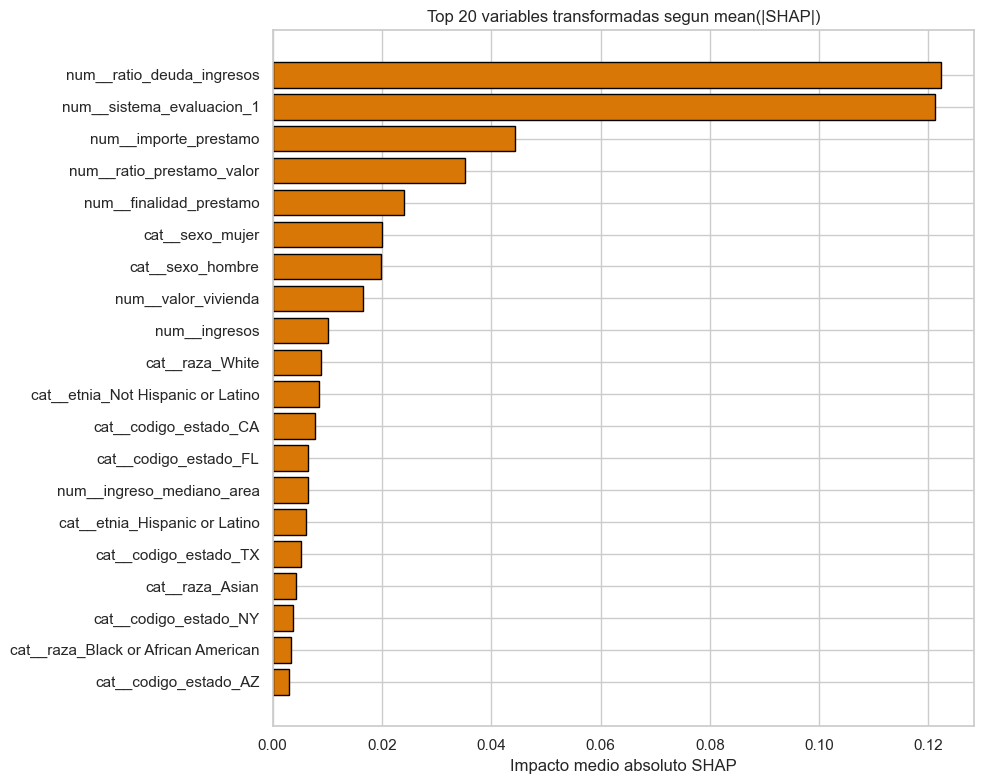

In [12]:
mean_abs_shap = np.abs(shap_values_df).mean(axis=0).sort_values(ascending=False)
global_shap_importance = mean_abs_shap.rename("mean_abs_shap").reset_index()
global_shap_importance.columns = ["feature", "mean_abs_shap"]

display(global_shap_importance.head(20))

plt.figure(figsize=(10, 8))
top_global = global_shap_importance.head(20).sort_values("mean_abs_shap")
plt.barh(top_global["feature"], top_global["mean_abs_shap"], color="#d97706", edgecolor="black")
plt.title("Top 20 variables transformadas segun mean(|SHAP|)")
plt.xlabel("Impacto medio absoluto SHAP")
plt.tight_layout()
plt.show()


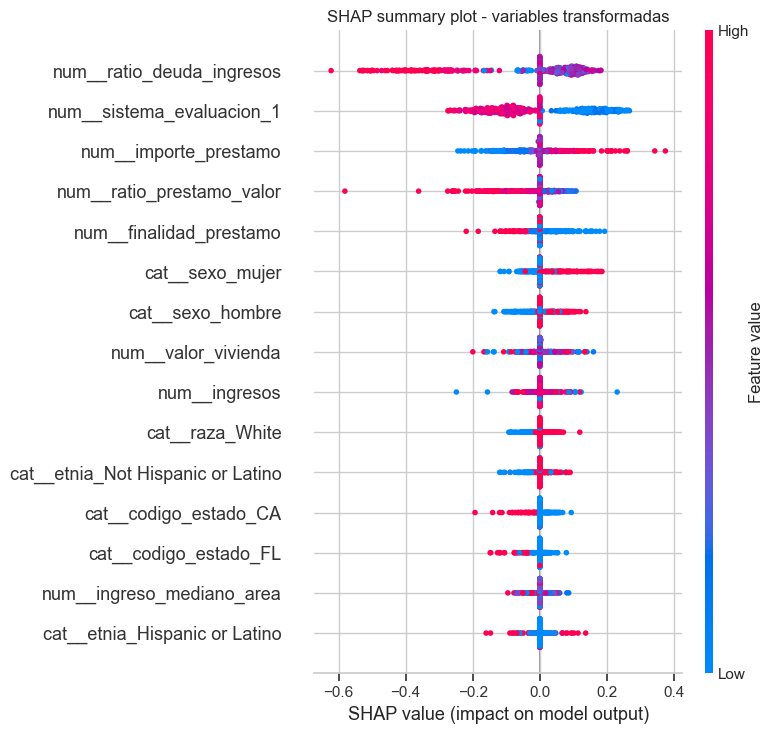

In [13]:
shap.summary_plot(shap_values_class1, X_explain_df, show=False, max_display=TOP_N)
plt.title("SHAP summary plot - variables transformadas")
plt.tight_layout()
plt.show()


## Agregacion SHAP por variable original

Como las variables categoricas se expanden con one-hot encoding, esta parte agrega las contribuciones SHAP de las columnas transformadas a la variable original. Esto queda mejor para el TFM.


,feature_original,mean_abs_shap
0,ratio_deuda_ingresos,0.122217
1,sistema_evaluacion_1,0.121251
2,codigo_estado,0.060950
3,importe_prestamo,0.044258
4,ratio_prestamo_valor,0.035264
5,sexo,0.025712
6,finalidad_prestamo,0.023943
7,raza,0.016845
8,valor_vivienda,0.016572
9,etnia,0.014739


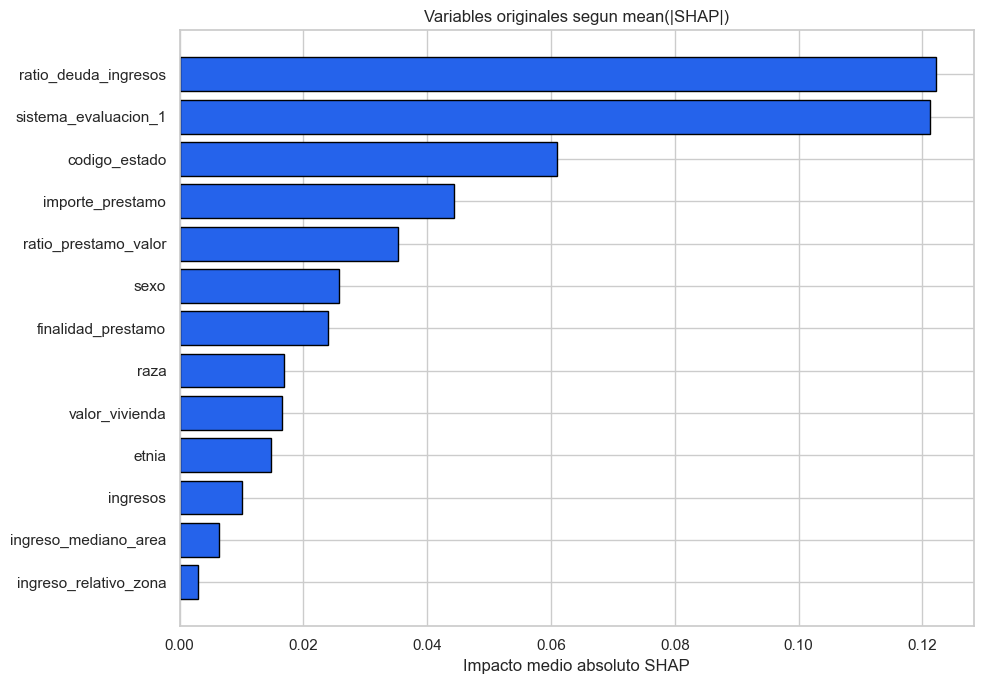

In [14]:
agg_shap_df, feature_mapping = aggregate_shap_by_original_feature(shap_values_df, categorical_cols)

agg_global_importance = (
    agg_shap_df.abs().mean(axis=0)
    .sort_values(ascending=False)
    .rename("mean_abs_shap")
    .reset_index()
)
agg_global_importance.columns = ["feature_original", "mean_abs_shap"]

display(agg_global_importance)

plt.figure(figsize=(10, 7))
top_agg = agg_global_importance.head(TOP_N).sort_values("mean_abs_shap")
plt.barh(top_agg["feature_original"], top_agg["mean_abs_shap"], color="#2563eb", edgecolor="black")
plt.title("Variables originales segun mean(|SHAP|)")
plt.xlabel("Impacto medio absoluto SHAP")
plt.tight_layout()
plt.show()


## Explicaciones locales

Aqui se selecciona un caso concreto del subconjunto explicado para ver que variables empujan la prediccion hacia la clase positiva o negativa.


In [16]:
explained_raw["prob_target_1"] = predict_positive_class(X_explain)
explained_raw["pred_target_1"] = (explained_raw["prob_target_1"] >= best_threshold).astype(int)

# Elegimos el caso con mayor probabilidad predicha para ilustrar una explicacion local intensa
local_idx = int(np.argmax(explained_raw["prob_target_1"].to_numpy()))
print("Indice local seleccionado dentro de la muestra explicada:", local_idx)
display(explained_raw.iloc[[local_idx]].T)


Indice local seleccionado dentro de la muestra explicada: 37


,31405
ratio_deuda_ingresos,41.0
importe_prestamo,12.721889
sistema_evaluacion_1,2
ingreso_mediano_area,97300
finalidad_prestamo,1
ingresos,0.0
ingreso_relativo_zona,131.62
valor_vivienda,12.959847
ratio_prestamo_valor,80.0
codigo_estado,MN


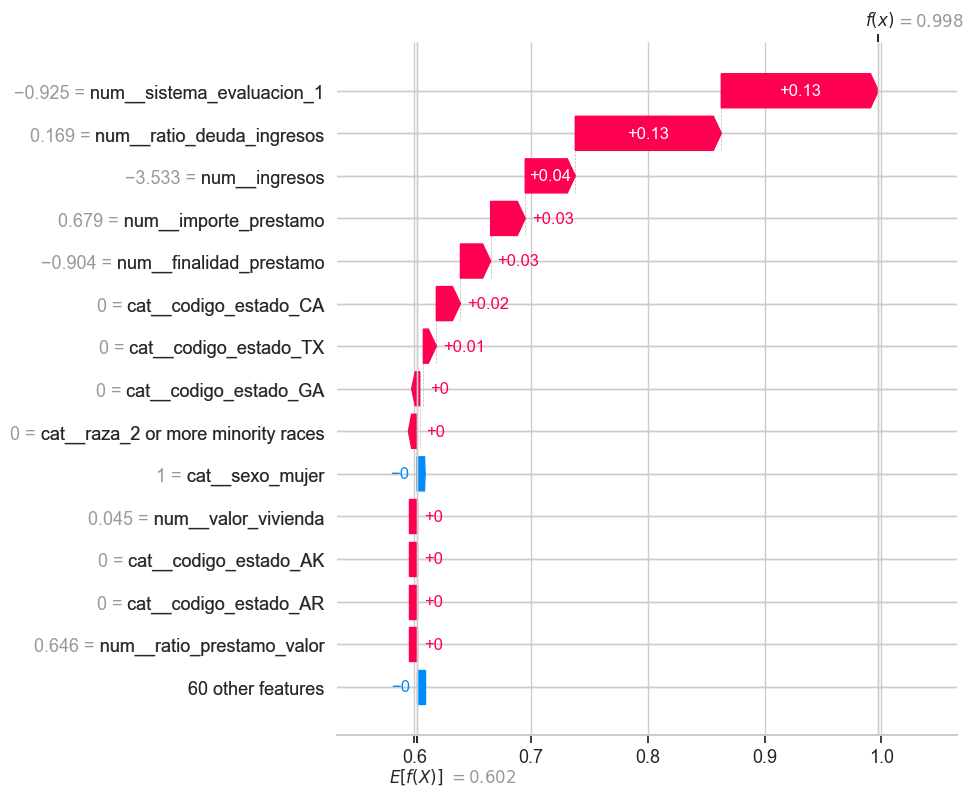

In [17]:
local_exp = shap.Explanation(
    values=shap_values_class1[local_idx],
    base_values=base_value,
    data=X_explain_df.iloc[local_idx].values,
    feature_names=X_explain_df.columns.tolist(),
)

shap.plots.waterfall(local_exp, max_display=TOP_N)


,feature_original,shap_value
0,sistema_evaluacion_1,0.134625
1,ratio_deuda_ingresos,0.125098
2,ingresos,0.042879
3,codigo_estado,0.034942
4,importe_prestamo,0.029655
5,finalidad_prestamo,0.025867
6,raza,0.002747
7,sexo,-0.000572
8,ingreso_mediano_area,0.000000
9,ratio_prestamo_valor,0.000000


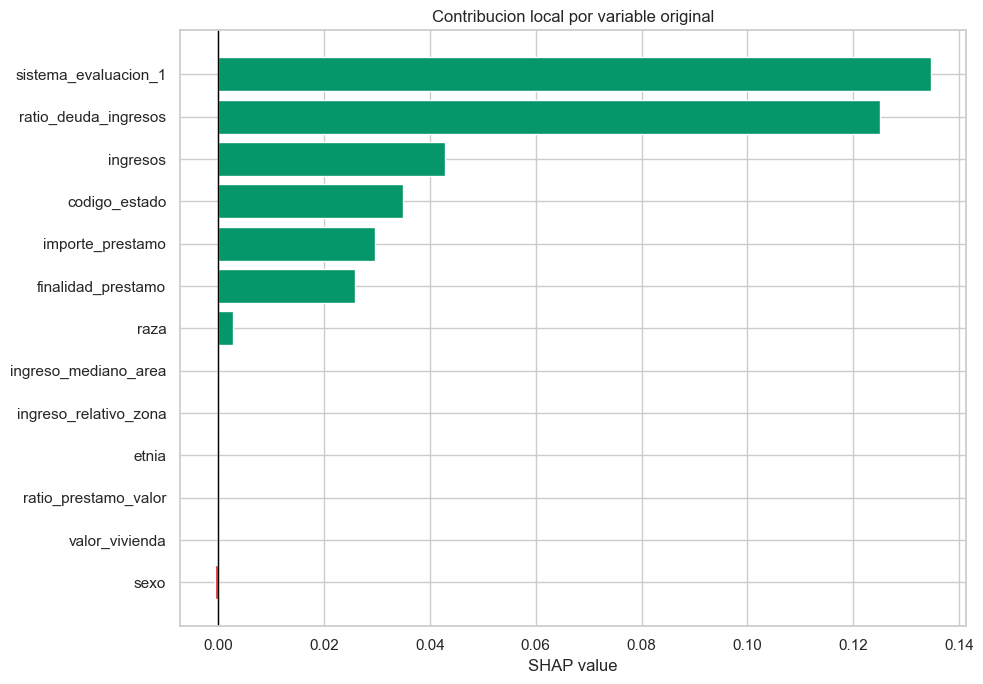

In [18]:
top_original_local = (
    agg_shap_df.iloc[local_idx]
    .sort_values(key=np.abs, ascending=False)
    .head(TOP_N)
    .rename("shap_value")
    .reset_index()
)
top_original_local.columns = ["feature_original", "shap_value"]
display(top_original_local)

plt.figure(figsize=(10, 7))
colors = ["#059669" if v > 0 else "#dc2626" for v in top_original_local["shap_value"]]
ordered = top_original_local.sort_values("shap_value")
plt.barh(ordered["feature_original"], ordered["shap_value"], color=["#dc2626" if v < 0 else "#059669" for v in ordered["shap_value"]])
plt.axvline(0, color="black", lw=1)
plt.title("Contribucion local por variable original")
plt.xlabel("SHAP value")
plt.tight_layout()
plt.show()


## Dependence plots SHAP

Se representan algunas de las variables originales mas influyentes para observar como cambia la contribucion marginal al variar su valor.


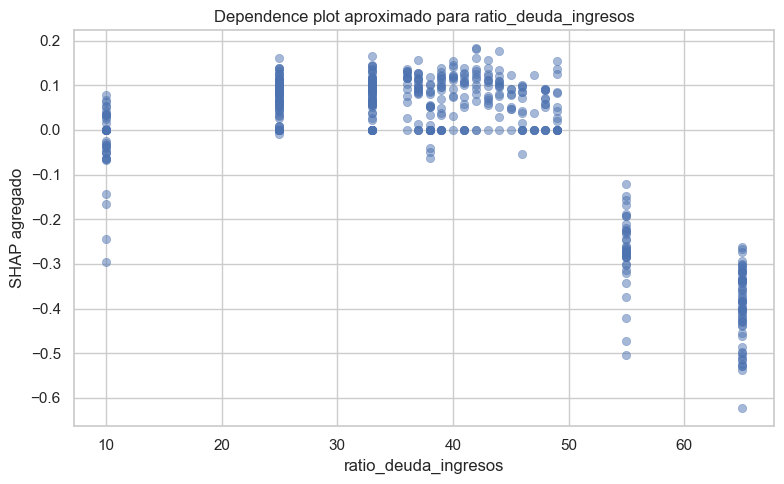

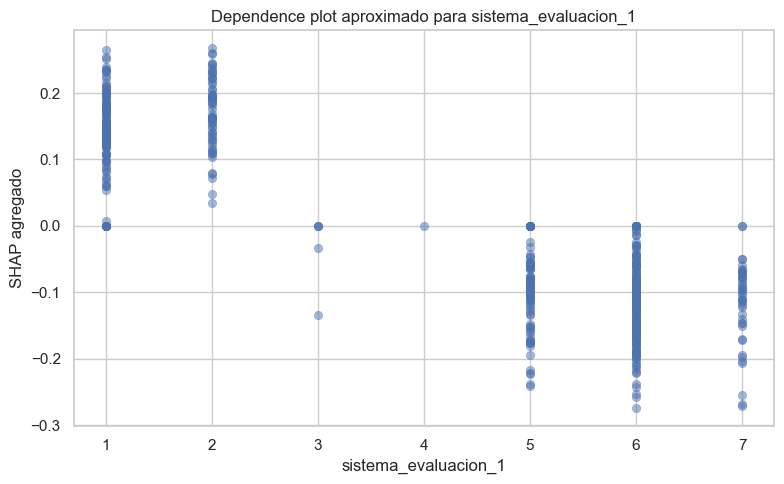

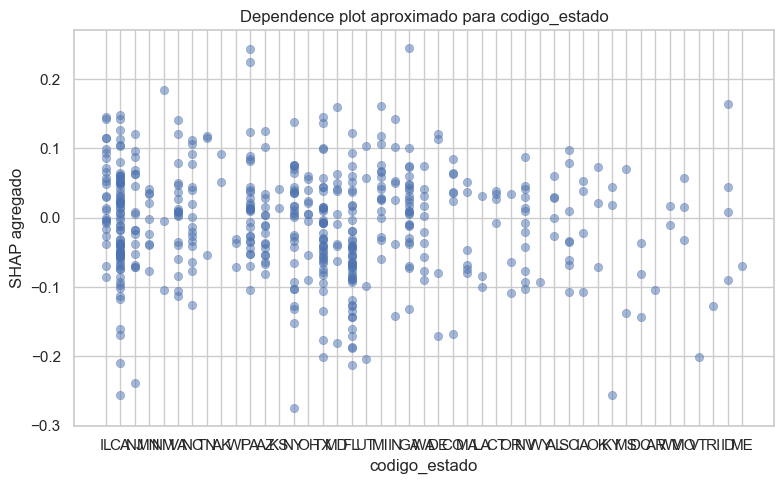

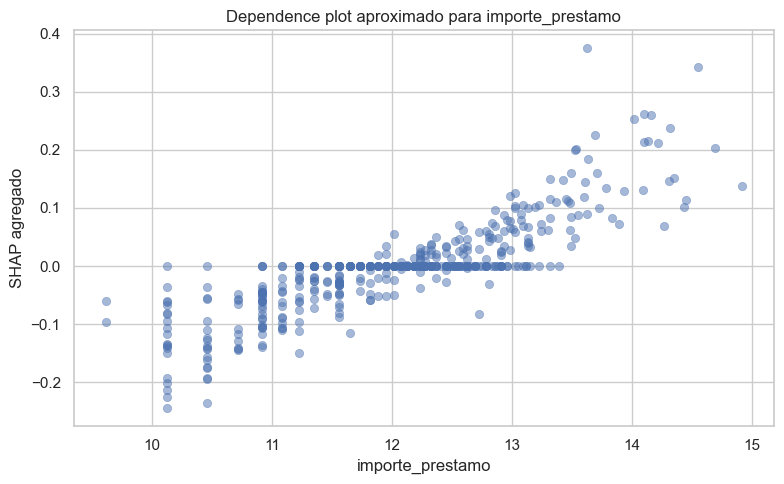

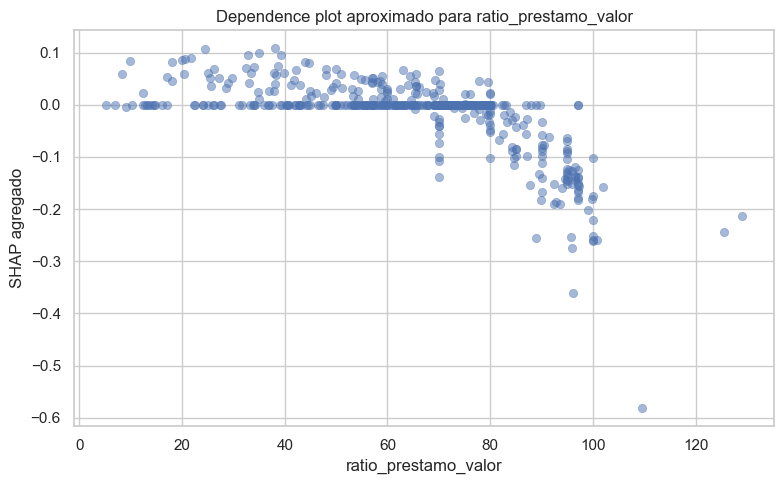

In [19]:
top_original_features = agg_global_importance.head(5)["feature_original"].tolist()
X_explain_original = explained_raw[[c for c in feature_cols if c in explained_raw.columns]].reset_index(drop=True)

for feature in top_original_features:
    if feature in X_explain_original.columns:
        plt.figure(figsize=(8, 5))
        sns.scatterplot(
            x=X_explain_original[feature],
            y=agg_shap_df[feature],
            alpha=0.5,
            edgecolor=None,
        )
        plt.title(f"Dependence plot aproximado para {feature}")
        plt.xlabel(feature)
        plt.ylabel("SHAP agregado")
        plt.tight_layout()
        plt.show()


## SHAP por subgrupos sensibles

Este bloque es exploratorio. Compara la importancia media absoluta agregada por variable original entre subgrupos sensibles en la muestra explicada.


sexo,hombre,mujer
ratio_deuda_ingresos,0.121238,0.123602
importe_prestamo,0.048171,0.038720
sistema_evaluacion_1,0.119777,0.123338
ingreso_mediano_area,0.006444,0.006375
finalidad_prestamo,0.022903,0.025416
ingresos,0.011081,0.008773
ingreso_relativo_zona,0.003108,0.002705
valor_vivienda,0.019075,0.013029
ratio_prestamo_valor,0.033956,0.037114
codigo_estado,0.057988,0.065142


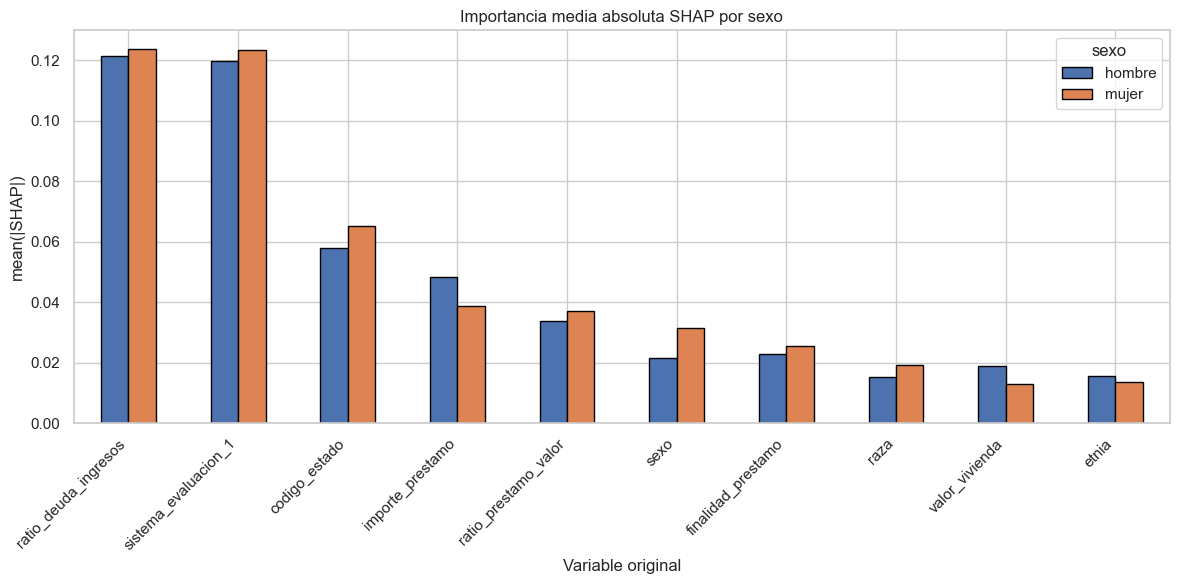

raza,2 or more minority races,American Indian or Alaska Native,Asian,Black or African American,Native Hawaiian or Other Pacific Islander,White
ratio_deuda_ingresos,0.273527,0.130040,0.161582,0.117885,0.065426,0.116380
importe_prestamo,0.107781,0.056677,0.058676,0.045153,0.082863,0.041535
sistema_evaluacion_1,0.050569,0.086015,0.113679,0.127467,0.220840,0.122193
ingreso_mediano_area,0.000000,0.010058,0.005253,0.003446,0.000000,0.006886
finalidad_prestamo,0.000000,0.019713,0.024756,0.025635,0.078862,0.023625
ingresos,0.000000,0.013451,0.006333,0.006808,0.028472,0.010982
ingreso_relativo_zona,0.000000,0.000000,0.002411,0.005466,0.000000,0.002810
valor_vivienda,0.000000,0.007478,0.015713,0.022964,0.000000,0.016239
ratio_prestamo_valor,0.000000,0.022835,0.030164,0.042500,0.000000,0.035627
codigo_estado,0.040306,0.106550,0.064680,0.072436,0.010021,0.058636


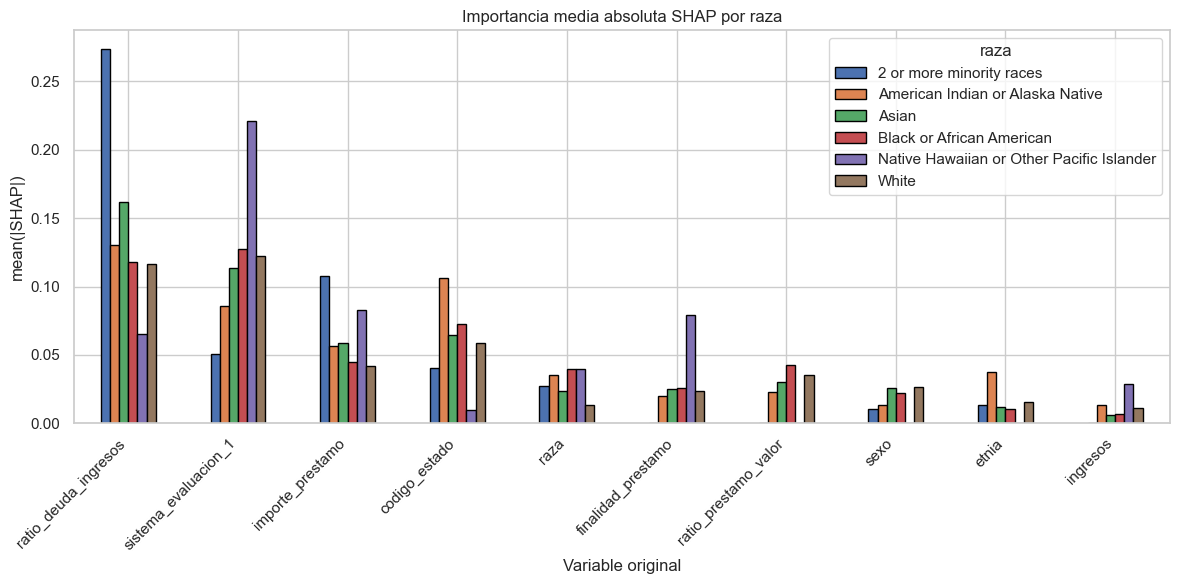

etnia,Ethnicity Not Available,Free Form Text Only,Hispanic or Latino,Joint,Not Hispanic or Latino
ratio_deuda_ingresos,0.136474,0.084050,0.133343,0.101110,0.120444
importe_prestamo,0.045788,0.098143,0.038060,0.053411,0.044827
sistema_evaluacion_1,0.160568,0.116154,0.131009,0.120939,0.118727
ingreso_mediano_area,0.003356,0.000000,0.008052,0.000000,0.006305
finalidad_prestamo,0.016250,0.112084,0.017709,0.012293,0.024672
ingresos,0.011808,0.000000,0.010568,0.000000,0.010183
ingreso_relativo_zona,0.001914,0.006851,0.002801,0.000000,0.002988
valor_vivienda,0.012076,0.026836,0.009855,0.000000,0.017930
ratio_prestamo_valor,0.060712,0.000000,0.024053,0.020343,0.037068
codigo_estado,0.054994,0.126511,0.060542,0.058322,0.060699


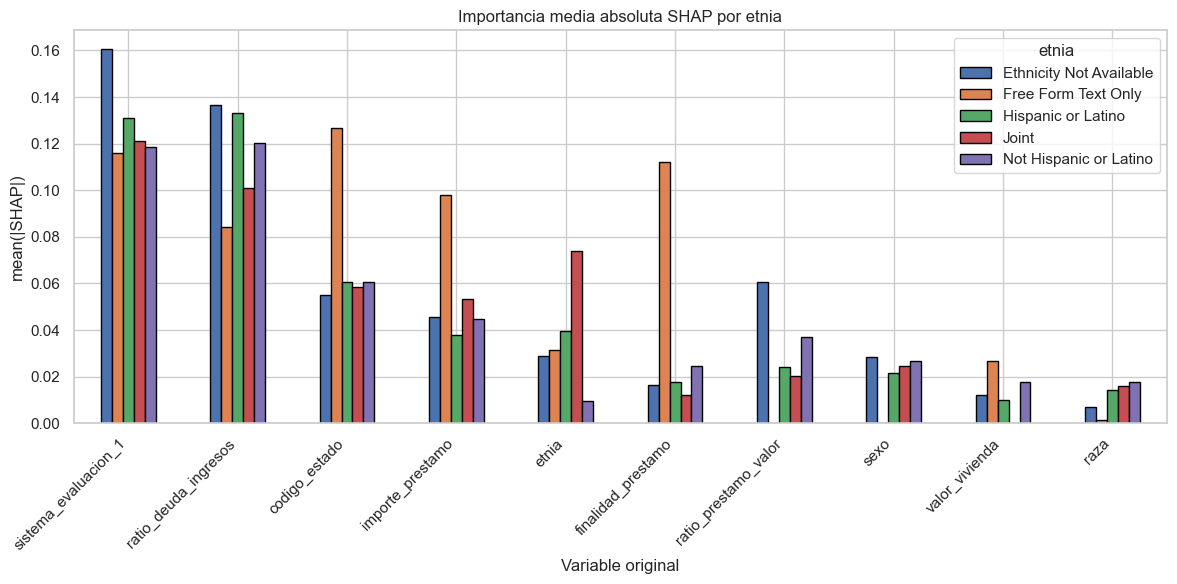

In [23]:
for sensitive_col in sensitive_cols:
    if sensitive_col not in explained_raw.columns:
        continue

    temp = agg_shap_df.copy()
    group_labels=explained_raw[sensitive_col].fillna("Missings").reset_index(drop=True)
 

    group_table =  temp.abs().groupby(group_labels).mean().T
    display(group_table.head(15))

    top_features_subgroup = group_table.mean(axis=1).sort_values(ascending=False).head(10).index
    plot_df = group_table.loc[top_features_subgroup].T

    plot_df.T.plot(kind="bar", figsize=(12, 6), edgecolor="black")
    plt.title(f"Importancia media absoluta SHAP por {sensitive_col}")
    plt.ylabel("mean(|SHAP|)")
    plt.xlabel("Variable original")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


## Tablas de resultados


In [24]:
shap_table_transformed = global_shap_importance.copy()
shap_table_original = agg_global_importance.copy()

display(shap_table_transformed.head(20))
display(shap_table_original.head(20))


,feature,mean_abs_shap
0,num__ratio_deuda_ingresos,0.122217
1,num__sistema_evaluacion_1,0.121251
2,num__importe_prestamo,0.044258
3,num__ratio_prestamo_valor,0.035264
4,num__finalidad_prestamo,0.023943
5,cat__sexo_mujer,0.019914
6,cat__sexo_hombre,0.019831
7,num__valor_vivienda,0.016572
8,num__ingresos,0.010126
9,cat__raza_White,0.008810


,feature_original,mean_abs_shap
0,ratio_deuda_ingresos,0.122217
1,sistema_evaluacion_1,0.121251
2,codigo_estado,0.060950
3,importe_prestamo,0.044258
4,ratio_prestamo_valor,0.035264
5,sexo,0.025712
6,finalidad_prestamo,0.023943
7,raza,0.016845
8,valor_vivienda,0.016572
9,etnia,0.014739


## Conclusiones interpretativas

SHAP permite analizar un modelo no lineal tanto de forma global como local. La agregación por variable original facilita la lectura de las variables transformadas y el análisis por subgrupos ayuda a comprobar si las explicaciones cambian entre colectivos.
